# Collect data over all EOM Voltage configurations

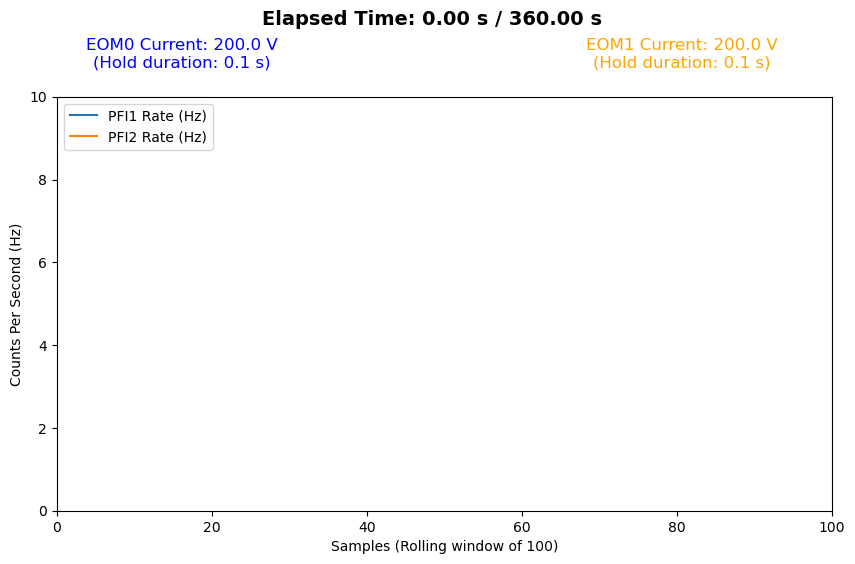

Hardware reset complete. Initializing DAQ tasks...
Sequence complete. DAQ tasks closed.
No data was recorded.


In [1]:
import nidaqmx
from nidaqmx.constants import Edge, CountDirection
import nidaqmx.system
import matplotlib.pyplot as plt
import collections
import time
import threading
import csv
import datetime
import os
import numpy as np

# ==========================================
# EXPERIMENTAL SEQUENCE PARAMETERS
# ==========================================
# timearray (seconds) defines how long each step lasts.
# signalarray (volts) defines the target voltage for the EOM during that step.
#timearray =    np.ones(120)*1
#signalarray1 = np.append(np.linspace(-200,200,60), np.zeros(60))
#signalarray0 = np.append(np.zeros(60), np.linspace(-200,200,60))

v_sweep = np.linspace(-200, 200, 60)

# This is the GUI window size. Note that it defaults to
# 100 counts per window. Decide this based on the length of each
# measurement in a natural way. So for example, for time_unit = 0.1,
# 100 counts per window corresponds to window scrolling completely
# through once roughly every two seconds, which is reasonable.
window_size = None

time_unit = 0.1 # seconds

# Total sequence time: 60 * 60 = 3600 units
timearray = np.ones(3600) * time_unit

# Sweeps from -200 to 200 repeatedly
signalarray0 = np.tile(v_sweep, 60)

# Steps from -200 to 200 slowly
signalarray1 = np.repeat(v_sweep, 60)

# Hardware Parameters
device_name = "Dev1"
ao_channel_0 = f"{device_name}/ao0"
ao_channel_1 = f"{device_name}/ao1"       
pfi_pin_0 = f"/{device_name}/PFI1"
pfi_pin_1 = f"/{device_name}/PFI2"
HV_GAIN = 20.0

# Ensure arrays are identically sized
assert len(timearray) == len(signalarray0) == len(signalarray1), "Input arrays must be the same length."
total_sequence_time = sum(timearray)

# ==========================================
# SHARED STATE & THREADING SETUP
# ==========================================
# Thread-safe data structures for passing data between DAQ and GUI
shared_state = {
    'is_running': True,
    'elapsed_time': 0.0,
    'current_step_duration': timearray[0],
    'current_v0': signalarray0[0],
    'current_v1': signalarray1[0],
    'rate0': 0.0,
    'rate1': 0.0
}

# Data structure to hold all points for the CSV export
# Format: list of tuples (Timestamp, Elapsed_Time, V0, V1, Raw_Count0, Raw_Count1, Rate0, Rate1)
recorded_data = []

# ==========================================
# DAQ WORKER THREAD (Strict hardware loop)
# ==========================================
def daq_worker():
    nidaqmx.system.Device(device_name).reset_device()
    print(f"Hardware reset complete. Initializing DAQ tasks...")
    
    try:
        with nidaqmx.Task() as ao_task, nidaqmx.Task() as ci_task0, nidaqmx.Task() as ci_task1:
            
            # Setup AO
            ao_task.ao_channels.add_ao_voltage_chan(ao_channel_0)
            ao_task.ao_channels.add_ao_voltage_chan(ao_channel_1)
            
            # Setup CI
            ci_chan0 = ci_task0.ci_channels.add_ci_count_edges_chan(
                f"{device_name}/ctr0", edge=Edge.RISING, initial_count=0, count_direction=CountDirection.COUNT_UP)
            ci_chan0.ci_count_edges_term = pfi_pin_0
            
            ci_chan1 = ci_task1.ci_channels.add_ci_count_edges_chan(
                f"{device_name}/ctr1", edge=Edge.RISING, initial_count=0, count_direction=CountDirection.COUNT_UP)
            ci_chan1.ci_count_edges_term = pfi_pin_1

            # Start Hardware
            ci_task0.start()
            ci_task1.start()
            ao_task.start()
            
            start_time = time.perf_counter()
            
            for step_idx in range(len(timearray)):
                if not shared_state['is_running']:
                    break
                
                # Setup current step parameters
                step_dur = timearray[step_idx]
                target_v0 = signalarray0[step_idx]
                target_v1 = signalarray1[step_idx]
                
                # Peter Note 9/2/26
                # The amplifier seemingly inverts the voltage. We are inverting to reverse this.
                # This inversion is erroneously reflected in the GUI automatically. Thus, later
                # in the GUI section we must invert before showing the voltage at the GUI.

                # Clamp and calculate DAQ voltage
                daq_v0 = -max(-10.0, min(10.0, target_v0 / HV_GAIN))
                daq_v1 = -max(-10.0, min(10.0, target_v1 / HV_GAIN))
                
                # Apply voltages to hardware immediately
                ao_task.write([daq_v0, daq_v1])

                # Update shared state for GUI
                shared_state['current_v0'] = daq_v0 * HV_GAIN
                shared_state['current_v1'] = daq_v1 * HV_GAIN
                shared_state['current_step_duration'] = step_dur
                
                # Grab initial counts at the start of the step
                c0_start = ci_task0.read()
                c1_start = ci_task1.read()
                step_start_time = time.perf_counter()
                
                # Wait for the duration of the interval (checking for early exit)
                while (time.perf_counter() - step_start_time) < step_dur:
                    if not shared_state['is_running']:
                        break
                    time.sleep(0.01) # Keeps thread responsive to stop commands
                
                if not shared_state['is_running']:
                    break
                
                # Grab final counts at the end of the step
                c0_end = ci_task0.read()
                c1_end = ci_task1.read()
                step_end_time = time.perf_counter()
                
                # Calculate average rate over the entire interval step
                dt = step_end_time - step_start_time
                hz0 = (c0_end - c0_start) / dt if dt > 0 else 0.0
                hz1 = (c1_end - c1_start) / dt if dt > 0 else 0.0
                
                shared_state['rate0'] = hz0
                shared_state['rate1'] = hz1
                
                now = time.perf_counter()
                elapsed = now - start_time
                shared_state['elapsed_time'] = elapsed
                
                # Save exact timestamp and single averaged data point to master record
                unix_timestamp = time.time()
                recorded_data.append((unix_timestamp, elapsed, target_v0, target_v1, c0_end, c1_end, hz0, hz1))
                    
    except Exception as e:
        print(f"DAQ Error: {e}")
    finally:
        shared_state['is_running'] = False
        print("Sequence complete. DAQ tasks closed.")

# Start DAQ thread
daq_thread = threading.Thread(target=daq_worker, daemon=True)
daq_thread.start()

# ==========================================
# GUI / MAIN THREAD (Monitoring Only)
# ==========================================
plt.ion()
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(top=0.8) # Leave room for clean status text at the top

# Set the window to the last 100 samples
if not window_size:
    window_size = 100 
plot_rate0 = collections.deque(maxlen=window_size)
plot_rate1 = collections.deque(maxlen=window_size)
plot_x = collections.deque(maxlen=window_size) # Track X coordinates for the rolling window

# Initialize empty lines
line0, = ax.plot([], [], label='PFI1 Rate (Hz)')
line1, = ax.plot([], [], label='PFI2 Rate (Hz)')
ax.legend(loc='upper left')
ax.set_xlabel(f"Samples (Rolling window of {window_size})")
ax.set_ylabel("Counts Per Second (Hz)")

# Status Text Elements
time_text = fig.text(0.5, 0.92, '', ha='center', fontsize=14, fontweight='bold')
v0_text = fig.text(0.25, 0.85, '', ha='center', fontsize=12, color='blue')
v1_text = fig.text(0.75, 0.85, '', ha='center', fontsize=12, color='orange')

last_plotted_elapsed = -1
sample_count = 0 # Track how many samples we've plotted for the X-axis

try:
    while shared_state['is_running'] and plt.fignum_exists(fig.number):
        elap = shared_state['elapsed_time']
        
        # Only update plot if a new step has finished and updated the state
        if elap > last_plotted_elapsed:
            v0 = shared_state['current_v0']
            v1 = shared_state['current_v1']
            step_dur = shared_state['current_step_duration']
            r0 = shared_state['rate0']
            r1 = shared_state['rate1']
            
            # Update text
            time_text.set_text(f"Elapsed Time: {elap:.2f} s / {total_sequence_time:.2f} s")
            v0_text.set_text(f"EOM0 Current: {-v0:.1f} V\n(Hold duration: {step_dur:.1f} s)")
            v1_text.set_text(f"EOM1 Current: {-v1:.1f} V\n(Hold duration: {step_dur:.1f} s)")
            
            # Update deques
            plot_rate0.append(r0)
            plot_rate1.append(r1)
            plot_x.append(sample_count)
            
            # Update BOTH X and Y data dynamically
            line0.set_data(plot_x, plot_rate0)
            line1.set_data(plot_x, plot_rate1)
            
            # Dynamically scale both X and Y axes
            ax.set_xlim(max(0, sample_count - window_size), max(window_size, sample_count))
            
            max_rate = max(max(plot_rate0), max(plot_rate1)) if len(plot_rate0) > 0 else 10
            ax.set_ylim(0, max(10, max_rate * 1.1))
            
            fig.canvas.flush_events()
            
            last_plotted_elapsed = elap
            sample_count += 1
            
        plt.pause(0.1) # Check state at 10Hz
        
except KeyboardInterrupt:
    print("Measurement interrupted by user.")
    shared_state['is_running'] = False

# Ensure thread closes gracefully if window was closed early
shared_state['is_running'] = False 
daq_thread.join(timeout=2.0)

plt.ioff()
plt.close(fig)

# ==========================================
# EXPORT DATA TO CSV
# ==========================================
if recorded_data:
    # Prompt the user for input in the terminal
    user_input = input("Sequence finished. Do you want to save the recorded data to CSV? (y/n): ").strip().lower()
    
    if user_input in ['y', 'yes']:
        run_id = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        trace_file = f"{run_id}_Detector_Traces.csv"
        profile_file = f"{run_id}_EOM_Profile.csv"
        
        # Save 1: Detector Traces
        with open(trace_file, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["Unix_Timestamp", "Elapsed_Time_s", "EOM0_Target_V", "EOM1_Target_V", "Raw_Count0", "Raw_Count1", "Rate0_Hz", "Rate1_Hz"])
            writer.writerows(recorded_data)
            
        # Save 2: Input Profiles
        with open(profile_file, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["Time_Duration_s", "EOM0_Voltage", "EOM1_Voltage"])
            for t, v0, v1 in zip(timearray, signalarray0, signalarray1):
                writer.writerow([t, v0, v1])

        print(f"Data successfully saved to:\n - {os.path.abspath(trace_file)}\n - {os.path.abspath(profile_file)}")
    else:
        print("Data discarded without saving.")
else:
    print("No data was recorded.")

# Fit theoretical curve to the data and extract EOM parameters

Trace 0 Fit Parameters (A, k1, k2, phi, C): [ 6.44786035e+03  7.51739600e-03  7.19045300e-03 -2.38739844e-01
  1.32544765e+03]
Trace 0 R^2:  0.9716263847089943
Trace 1 Fit Parameters (A, k1, k2, phi, C): [-4.84575372e+03  7.63368100e-03  7.15946800e-03 -2.36279138e-01
  5.97087004e+03]
Trace 1 R^2:  0.974651288767639


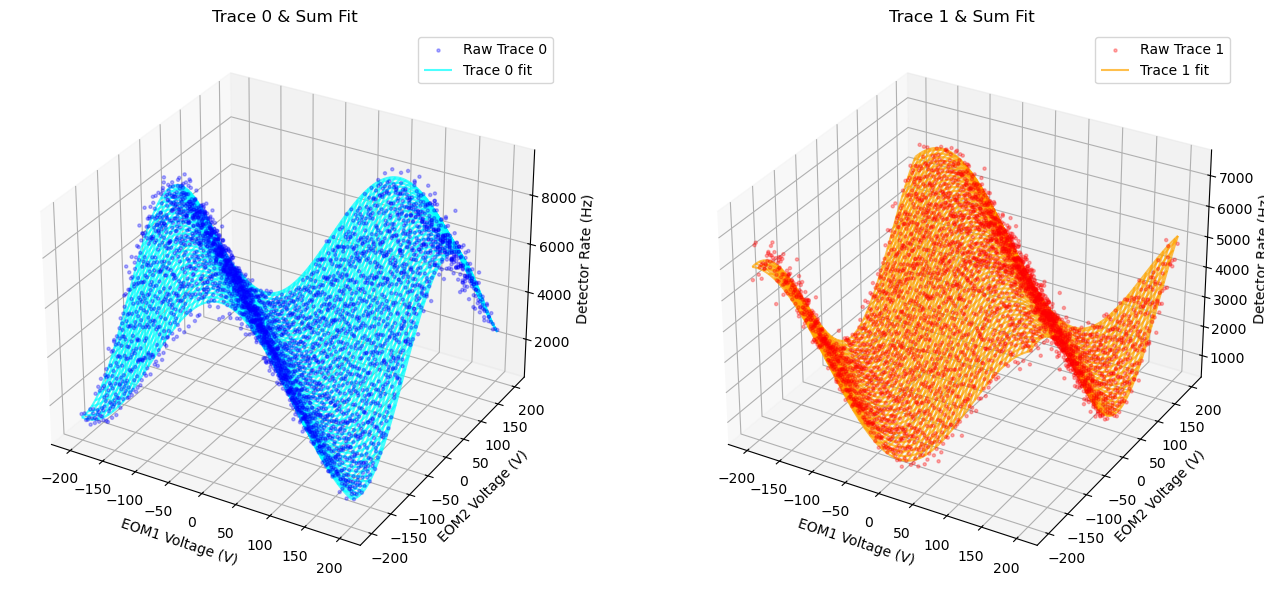

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import curve_fit

# 1. Define the measurement logic arrays
v_sweep = np.linspace(-200, 200, 60)
signalarray0 = np.tile(v_sweep, 60)
signalarray1 = np.repeat(v_sweep, 60)

# 2. Load the detector trace data
df = pd.read_csv("20260911_165206_Detector_Traces.csv")
z0 = df['Rate0_Hz'].values
z1 = df['Rate1_Hz'].values

# 3. Define the updated 2D interference fitting function
def new_eom_model(xy, A, k1, k2, phi, C):
    x, y = xy
    return A * (np.sin(k1 * x + k2 * y + phi)**2) + C

# 4. Execute the curve fitting for both traces
# Initial parameter guesses: [Amplitude, k1, k2, phi, Offset]
p0_guess0 = [np.max(z0) - np.min(z0), 0.01, 0.01, 0, np.min(z0)]
try:
    popt0, pcov0 = curve_fit(new_eom_model, (signalarray0, signalarray1), z0, p0=p0_guess0)
except RuntimeError:
    # Fallback guess if optimization fails to converge
    print("Fitting to Trace 0 failed to converge")

p0_guess1 = [np.max(z1) - np.min(z1), 0.01, 0.01, 0, np.min(z1)]
try:
    popt1, pcov1 = curve_fit(new_eom_model, (signalarray0, signalarray1), z1, p0=p0_guess1)
except RuntimeError:
    # Fallback guess if optimization fails to converge
    print("Fitting to Trace 1 failed to converge")

# CALCULATING R^2 VALUES

# Calculate the predicted Z values using the optimized parameters
z0_fit = new_eom_model((signalarray0, signalarray1), *popt0)
# Calculate the Residual Sum of Squares (SS_res)
ss_res0 = np.sum((z0 - z0_fit)**2)
# Calculate the Total Sum of Squares (SS_tot)
ss_tot0 = np.sum((z0 - np.mean(z0))**2)
# Compute R^2
r_squared0 = 1 - (ss_res0 / ss_tot0)

# Calculate the predicted Z values using the optimized parameters
z1_fit = new_eom_model((signalarray0, signalarray1), *popt1)
# Calculate the Residual Sum of Squares (SS_res)
ss_res1 = np.sum((z1 - z1_fit)**2)
# Calculate the Total Sum of Squares (SS_tot)
ss_tot1 = np.sum((z1 - np.mean(z0))**2)
# Compute R^2
r_squared1 = 1 - (ss_res1 / ss_tot1)


print(f"Trace 0 Fit Parameters (A, k1, k2, phi, C): {np.round(popt0, 9)}")
print(f"Trace 0 R^2: ", r_squared0)
print(f"Trace 1 Fit Parameters (A, k1, k2, phi, C): {np.round(popt1, 9)}")
print(f"Trace 1 R^2: ", r_squared1)

# 5. Generate a high-resolution meshgrid for smooth surface plotting
X, Y = np.meshgrid(np.linspace(-200, 200, 100), np.linspace(-200, 200, 100))
Z0_fit = new_eom_model((X, Y), *popt0)
Z1_fit = new_eom_model((X, Y), *popt1)

# 6. Initialize the 3D plot with two subplots
fig = plt.figure(figsize=(14, 6))

# Subplot 1: Trace 0
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(signalarray0, signalarray1, z0, c='blue', s=5, alpha=0.3, label='Raw Trace 0')
ax1.plot_wireframe(X, Y, Z0_fit, color='cyan', alpha=0.7, label='Trace 0 fit')
ax1.set_xlabel('EOM1 Voltage (V)')
ax1.set_ylabel('EOM2 Voltage (V)')
ax1.set_zlabel('Detector Rate (Hz)')
ax1.set_title('Trace 0 & Sum Fit')
ax1.legend()

# Subplot 2: Trace 1
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(signalarray0, signalarray1, z1, c='red', s=5, alpha=0.3, label='Raw Trace 1')
ax2.plot_wireframe(X, Y, Z1_fit, color='orange', alpha=0.7, label='Trace 1 fit')
ax2.set_xlabel('EOM1 Voltage (V)')
ax2.set_ylabel('EOM2 Voltage (V)')
ax2.set_zlabel('Detector Rate (Hz)')
ax2.set_title('Trace 1 & Sum Fit')
ax2.legend()

plt.tight_layout()
plt.show()

# Decide EOM voltages for BB84 photon manipulation

EOM0_VPI 208.95485799257565
EOM1_VPI 218.45581048212853
EOM0Voltages =  [np.float64(-177.19653941192604), np.float64(-72.71911041563821), np.float64(31.758318580649615), np.float64(136.23574757693746)]
EOM1Voltages =  [0, np.float64(109.22790524106426)]


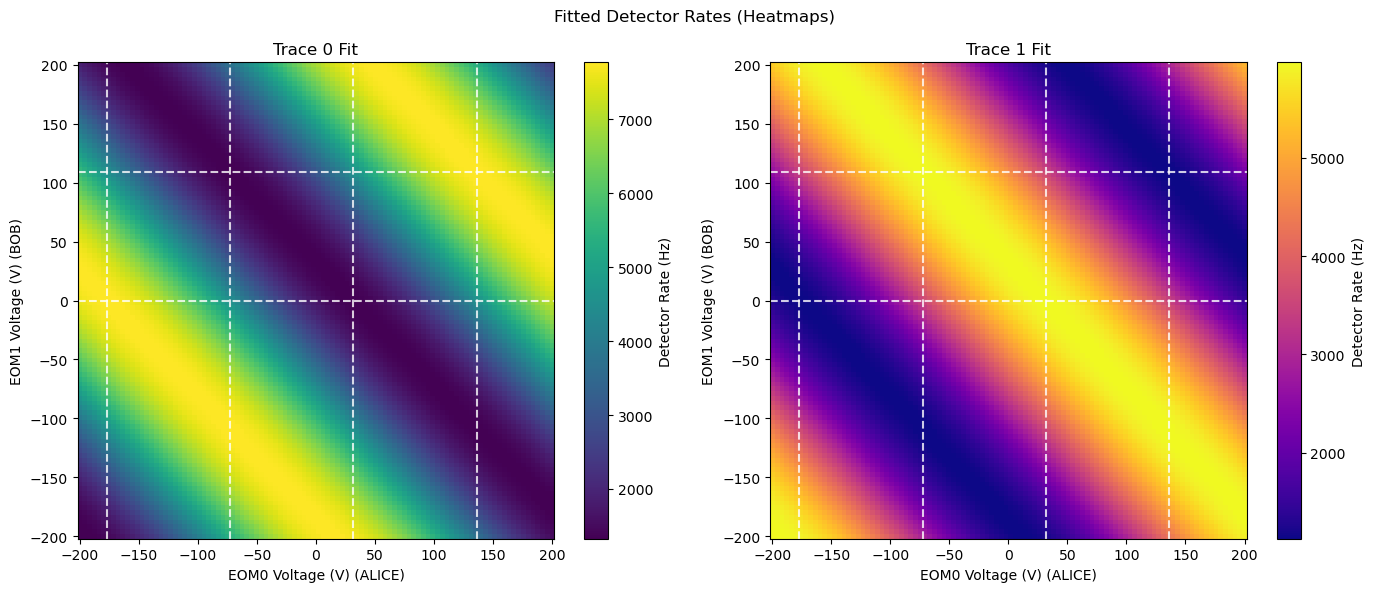

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the fitted interference model
def new_eom_model(x, y, A, k1, k2, phi, C):
    return A * (np.sin(k1 * x + k2 * y + phi)**2) + C

# 2. Input the provided optimal fit parameters
params0 = popt0
params1 = popt1

# 3. Generate a meshgrid
X, Y = np.meshgrid(np.linspace(-200, 200, 100), np.linspace(-200, 200, 100))

# 4. Calculate the corresponding Z (Rate) values
Z0_fit = new_eom_model(X, Y, *params0)
Z1_fit = new_eom_model(X, Y, *params1)

# 5. Initialize the 2D subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 6. Plot using pcolormesh for the heatmaps
c1 = ax1.pcolormesh(X, Y, Z0_fit, cmap='viridis', shading='auto')
c2 = ax2.pcolormesh(X, Y, Z1_fit, cmap='plasma', shading='auto')
fig.colorbar(c1, ax=ax1, label='Detector Rate (Hz)')
fig.colorbar(c2, ax=ax2, label='Detector Rate (Hz)')

# 7. Set voltages for all states based on EOM parameters, and plot
# vertical/horizontal lines for each voltage for visual verification
EOM0_VPI = np.pi/params0[1]/2
EOM1_VPI = np.pi/params0[2]/2

print('EOM0_VPI', EOM0_VPI)
print('EOM1_VPI', EOM1_VPI)

V_EOM0_set_0 = -params0[3]/params0[1] - EOM0_VPI

# --- Add vertical and horizontal lines ---
V_EOM0_set_1 = V_EOM0_set_0  # Set your desired X-coordinate
V_EOM0_set_2 = V_EOM0_set_0 + EOM0_VPI/2 
V_EOM0_set_3 = V_EOM0_set_0 + 2*EOM0_VPI/2 
V_EOM0_set_4 = V_EOM0_set_0 + 3*EOM0_VPI/2 

EOM0Voltages = [V_EOM0_set_1, V_EOM0_set_2, V_EOM0_set_3, V_EOM0_set_4]

ax1.axvline(x=V_EOM0_set_1, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axvline(x=V_EOM0_set_1, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.axvline(x=V_EOM0_set_2, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axvline(x=V_EOM0_set_2, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.axvline(x=V_EOM0_set_3, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axvline(x=V_EOM0_set_3, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.axvline(x=V_EOM0_set_4, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axvline(x=V_EOM0_set_4, color='white', linestyle='--', linewidth=1.5, alpha=0.8)

V_EOM1_set_1 = 0  # Set your desired Y-coordinate
V_EOM1_set_2 = 0 + EOM1_VPI/2

EOM1Voltages = [V_EOM1_set_1, V_EOM1_set_2]

ax1.axhline(y=V_EOM1_set_1, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axhline(y=V_EOM1_set_1, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.axhline(y=V_EOM1_set_2, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axhline(y=V_EOM1_set_2, color='white', linestyle='--', linewidth=1.5, alpha=0.8)

print('EOM0Voltages = ', EOM0Voltages)
print('EOM1Voltages = ', EOM1Voltages)

# 8. Format the axes and titles
ax1.set_xlabel('EOM0 Voltage (V) (ALICE)')
ax1.set_ylabel('EOM1 Voltage (V) (BOB)')
ax1.set_title('Trace 0 Fit')

ax2.set_xlabel('EOM0 Voltage (V) (ALICE)')
ax2.set_ylabel('EOM1 Voltage (V) (BOB)')
ax2.set_title('Trace 1 Fit')

fig.suptitle('Fitted Detector Rates (Heatmaps)')

# 9. Display the plot
plt.tight_layout()
plt.show()

# Plot four by four BB84 protocol logic matrix

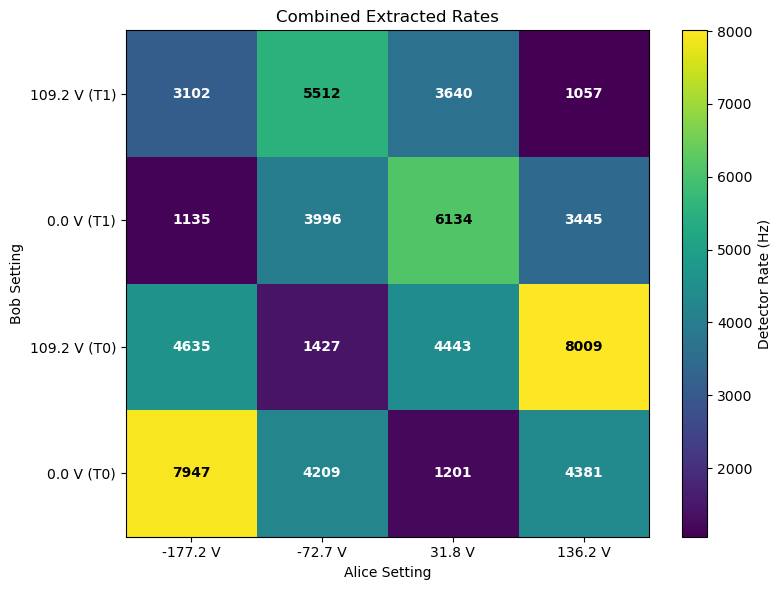

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the measurement logic arrays
v_sweep = np.linspace(-200, 200, 60)
signalarray0 = np.tile(v_sweep, 60)
signalarray1 = np.repeat(v_sweep, 60)

# 3. Extract the 8 closest points into 2x4 matrices
rate0_grid = np.zeros((2, 4))
rate1_grid = np.zeros((2, 4))

for i, v1_ideal in enumerate(EOM1Voltages):
    for j, v0_ideal in enumerate(EOM0Voltages):
        distances = (signalarray0 - v0_ideal)**2 + (signalarray1 - v1_ideal)**2
        idx = np.argmin(distances)
        
        rate0_grid[i, j] = z0[idx]
        rate1_grid[i, j] = z1[idx]

# 4. Combine the grids into a single 4x4 matrix
# np.vstack puts rate0_grid at indices 0,1 and rate1_grid at 2,3.
# With origin='lower', indices 2,3 (Trace 1) appear above indices 0,1 (Trace 0).
combined_grid = np.vstack((rate0_grid, rate1_grid))

# Combine Y-axis labels to distinguish the traces
combined_y_labels = [f"{v:.1f} V (T0)" for v in EOM1Voltages] + [f"{v:.1f} V (T1)" for v in EOM1Voltages]

# 5. Plot the 4x4 heatmap
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(combined_grid, origin='lower', cmap='viridis', aspect='auto')

# 6. Add colorbar shared for both traces
fig.colorbar(im, ax=ax, label='Detector Rate (Hz)')

# 7. Format axes and annotate values
ax.set_xticks(np.arange(len(EOM0Voltages)))
ax.set_yticks(np.arange(len(combined_y_labels)))

x_labels = [f"{v:.1f} V" for v in EOM0Voltages]

# Label ticks with rounded voltage values and trace identifiers
ax.set_xticklabels(x_labels)
ax.set_yticklabels(combined_y_labels)

ax.set_xlabel('Alice Setting')
ax.set_ylabel('Bob Setting')
ax.set_title('Combined Extracted Rates')

# Annotate each cell with the exact count rate
threshold = np.max(combined_grid) * 0.6  # Threshold for text color contrast
for i in range(combined_grid.shape[0]):
    for j in range(combined_grid.shape[1]):
        val = combined_grid[i, j]
        text_color = "white" if val < threshold else "black"
        ax.text(j, i, f"{int(val)}", ha="center", va="center", color=text_color, fontweight='bold')

# 8. Display the plot
plt.tight_layout()
plt.show()


